# 🐝 Ejemplo 1 — Selección de características (*Feature Selection*) con **ABC** (Artificial Bee Colony)

**Curso:** Inteligencia de enjambre · **Entorno:** Google Colab (Python 3)

**Objetivo.** Usar el algoritmo de la Colonia Artificial de Abejas (ABC) para encontrar el **mejor subconjunto de características** de un conjunto de datos, de modo que un clasificador de aprendizaje de máquina:

1. mantenga (o mejore) su **exactitud**, y
2. utilice el **menor número posible de variables**.

**Contenido del cuaderno**

| Sección | Contenido |
|---|---|
| 1 | Fundamento teórico (para el informe) |
| 2 | Datos y configuración |
| 3 | Ciclo del algoritmo de enjambre: representación → inicialización → aptitud → comportamiento → evolución → finalización |
| 4 | Ejecución y resultados |
| 5 | Evaluación final en datos de prueba y comparación con línea base |
| 6 | Robustez (varias ejecuciones) y comparación contra búsqueda aleatoria |
| 7 | Conclusiones |

## 1. Fundamento teórico

### 1.1 ¿Qué es *feature selection*?
Dado un conjunto de datos con $D$ características, *feature selection* busca un subconjunto $S \subseteq \{1,\dots,D\}$ que **maximice el desempeño del modelo** y **minimice $|S|$**. Se trata de un problema de optimización combinatoria: existen $2^D$ subconjuntos posibles (con $D=30$ ya son más de $10^9$), por lo que la búsqueda exhaustiva es inviable y se recurre a metaheurísticas como los algoritmos de enjambre.

Se usa el enfoque **wrapper**: el clasificador se entrena y evalúa *dentro* de la función de aptitud, de modo que cada subconjunto se juzga por el desempeño real del modelo.

### 1.2 ¿Qué es ABC?
*Artificial Bee Colony* (Karaboga, 2005) imita el forrajeo de las abejas melíferas. La colonia tiene tres tipos de abejas:

| Abeja | Rol biológico | Rol en el algoritmo |
|---|---|---|
| **Empleada** | Explota una fuente de alimento conocida | Cada una está asociada a **una solución** y busca una vecina mejor (explotación local) |
| **Observadora** | Observa la "danza" y elige fuente según su calidad | Elige soluciones con **probabilidad proporcional a su aptitud** (ruleta) y las refina (intensificación) |
| **Exploradora** | Abandona fuentes agotadas y busca nuevas | Si una solución no mejora tras `limit` intentos, se **reemplaza por una aleatoria** (exploración) |

**Operador de vecindad** (para la fuente $i$, dimensión $j$, con $k \neq i$ aleatorio):

$$v_{ij} = x_{ij} + \phi_{ij}\,(x_{ij} - x_{kj}), \qquad \phi_{ij}\sim U(-1,1)$$

**Selección voraz (greedy):** si $f(v_i) < f(x_i)$ se reemplaza $x_i$ por $v_i$; si no, se incrementa el contador de intentos fallidos $trial_i$.

**Probabilidad de las observadoras:**

$$p_i = \frac{fit_i}{\sum_{n=1}^{SN} fit_n}, \qquad fit_i = \frac{1}{1 + cost_i}$$

### 1.3 Adaptación de ABC (continuo) a un problema binario
ABC trabaja con posiciones continuas, pero la selección de características es binaria. Se usa la representación **continua + umbral**: cada fuente de alimento es un vector $x\in[0,1]^D$ y la característica $j$ se **selecciona si $x_j > 0.5$**. Así se conservan intactos los operadores originales de ABC.

### 1.4 Función de aptitud (a minimizar)

$$cost(x) = \alpha\,\bigl(1 - Acc_{CV}(x)\bigr) + (1-\alpha)\,\frac{|S(x)|}{D}$$

- $Acc_{CV}$: exactitud media en validación cruzada estratificada de 5 pliegues (**solo con datos de entrenamiento**).
- $|S(x)|/D$: proporción de características usadas.
- $\alpha = 0.99$: prioriza la exactitud y usa el número de variables como criterio de desempate/penalización.

## 2. Datos y configuración

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3})
SEED = 42

**Conjunto de datos:** *Breast Cancer Wisconsin (Diagnostic)* incluido en scikit-learn: 569 muestras, **30 características** numéricas (medias, errores estándar y peores valores de 10 propiedades del núcleo celular) y una clase binaria (maligno / benigno).

Se separa un **30 % de prueba** que el algoritmo **nunca ve** durante la búsqueda; así la mejora que se reporte al final no está contaminada por el proceso de optimización.

In [ ]:
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = np.array(data.feature_names)
D = X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
print(f"Muestras: {X.shape[0]} | Características (D): {D}")
print(f"Entrenamiento: {X_train.shape} | Prueba: {X_test.shape}")
print("Clases:", dict(zip(data.target_names, np.bincount(y))))
pd.DataFrame(X_train, columns=feature_names).iloc[:, :6].describe().T.round(2)

Muestras: 569 | Características (D): 30
Entrenamiento: (398, 30) | Prueba: (171, 30)
Clases: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


,count,mean,std,min,25%,50%,75%,max
mean radius,398.0,14.09,3.49,6.98,11.66,13.27,15.77,25.73
mean texture,398.0,19.34,4.50,9.71,15.99,18.82,21.83,39.28
mean perimeter,398.0,91.70,24.06,43.79,74.90,86.04,103.68,174.20
mean area,398.0,650.78,340.30,143.50,417.10,544.05,777.40,2010.00
mean smoothness,398.0,0.10,0.01,0.06,0.09,0.10,0.10,0.14
mean compactness,398.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35


### Hiperparámetros del enjambre

In [ ]:
SN       = 15      # nº de fuentes de alimento (= nº de abejas empleadas = nº de observadoras)
MAX_ITER = 40      # criterio de finalización: nº máximo de ciclos
LIMIT    = 8       # ciclos sin mejora antes de que una fuente sea abandonada (abeja exploradora)
MR       = 0.30    # tasa de modificación: prob. de que cada dimensión sea perturbada
ALPHA    = 0.99    # peso de la exactitud frente al nº de características
THRESH   = 0.5     # umbral para binarizar la posición (x_j > THRESH -> característica seleccionada)

# Clasificador "wrapper" y esquema de validación (solo sobre el conjunto de entrenamiento)
def make_model():
    return make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

## 3. Ciclo del algoritmo de enjambre

### 3.1 Representación de la partícula (fuente de alimento)
Cada **fuente de alimento** es un vector real $x = (x_1,\dots,x_{30}) \in [0,1]^{30}$.
La **máscara binaria** asociada es $m_j = 1$ si $x_j > 0.5$; solo las características con $m_j=1$ se entregan al clasificador.

```
x    = [0.83, 0.12, 0.61, 0.07, 0.95, ...]
mask = [  1 ,   0 ,   1 ,   0 ,   1 , ...]   →  se usan las características 1, 3, 5, ...
```

### 3.3 Función de aptitud
Se define primero la función de aptitud porque es la que "evalúa" a cada partícula. Se incluye una **caché** para no reentrenar el modelo cuando se repite un mismo subconjunto.

In [ ]:
def position_to_mask(pos):
    # Representación: vector continuo en [0,1]^D  ->  máscara binaria de características.
    return pos > THRESH


_cache = {}          # {máscara(bytes): (costo, exactitud_cv)}
n_real_evals = 0     # nº de evaluaciones reales (sin contar aciertos de caché)

def evaluate(pos):
    # Función de aptitud (a MINIMIZAR). Devuelve (costo, exactitud_cv, nº_características).
    global n_real_evals
    mask = position_to_mask(pos)
    n_sel = int(mask.sum())
    if n_sel == 0:                                   # subconjunto vacío: solución inválida
        return 1.0, 0.0, 0
    key = mask.tobytes()
    if key not in _cache:
        n_real_evals += 1
        acc = cross_val_score(make_model(), X_train[:, mask], y_train,
                              cv=cv, scoring="accuracy").mean()
        cost = ALPHA * (1.0 - acc) + (1.0 - ALPHA) * n_sel / D
        _cache[key] = (cost, acc)
    cost, acc = _cache[key]
    return cost, acc, n_sel


# Punto de referencia: usar las 30 características
c_all, acc_all_cv, _ = evaluate(np.ones(D))
print(f"Línea base (30 características) → exactitud CV = {acc_all_cv:.4f} | costo = {c_all:.4f}")

Línea base (30 características) → exactitud CV = 0.9674 | costo = 0.0423


### 3.2 Inicialización del enjambre
Las $SN$ fuentes de alimento se generan de forma **uniforme aleatoria** en $[0,1]^D$:
$x_{ij} = U(0,1)$. Con este esquema, cada característica tiene ≈50 % de probabilidad inicial de ser seleccionada, lo que da diversidad máxima.

### 3.4 Comportamiento de las partículas (abejas)
Se implementan las tres fases de ABC:

* **`neighbour`**: operador de vecindad $v_{ij}=x_{ij}+\phi_{ij}(x_{ij}-x_{kj})$ aplicado a un subconjunto aleatorio de dimensiones (tasa `MR`), con recorte a $[0,1]$.
* **Abejas empleadas**: cada una perturba su fuente y aplica selección voraz.
* **Abejas observadoras**: eligen fuentes por ruleta según $p_i$ y las perturban.
* **Abejas exploradoras**: reinician las fuentes cuyo contador `trial` supera `LIMIT`.

In [ ]:
class Swarm:
    # Estado de la colonia de abejas.
    def __init__(self, rng):
        self.rng = rng
        # ---- 3.2 INICIALIZACIÓN --------------------------------------------------
        self.pos = rng.random((SN, D))                       # posiciones en [0,1]^D
        res = [evaluate(p) for p in self.pos]
        self.cost   = np.array([r[0] for r in res])
        self.acc    = np.array([r[1] for r in res])
        self.nfeat  = np.array([r[2] for r in res])
        self.trials = np.zeros(SN, dtype=int)                # intentos fallidos por fuente
        # mejor solución global (memoria del enjambre)
        b = self.cost.argmin()
        self.best_pos, self.best_cost = self.pos[b].copy(), self.cost[b]
        self.best_acc, self.best_nfeat = self.acc[b], self.nfeat[b]

    # ---- 3.4 COMPORTAMIENTO ------------------------------------------------------
    def neighbour(self, i):
        # v_ij = x_ij + phi*(x_ij - x_kj) sobre un subconjunto de dimensiones.
        k = self.rng.choice([n for n in range(SN) if n != i])          # compañera k != i
        dims = self.rng.random(D) < MR                                 # dimensiones a perturbar
        if not dims.any():
            dims[self.rng.integers(D)] = True                          # al menos una dimensión
        phi = self.rng.uniform(-1, 1, D)
        v = self.pos[i].copy()
        v[dims] = self.pos[i, dims] + phi[dims] * (self.pos[i, dims] - self.pos[k, dims])
        return np.clip(v, 0.0, 1.0)

    def greedy_update(self, i):
        # Genera vecino, lo evalúa y lo acepta solo si mejora (selección voraz).
        v = self.neighbour(i)
        c, a, n = evaluate(v)
        if c < self.cost[i]:
            self.pos[i], self.cost[i], self.acc[i], self.nfeat[i] = v, c, a, n
            self.trials[i] = 0
        else:
            self.trials[i] += 1

    def employed_phase(self):
        for i in range(SN):
            self.greedy_update(i)

    def onlooker_phase(self):
        fit = 1.0 / (1.0 + self.cost)                # aptitud (mayor = mejor)
        p = fit / fit.sum()                          # probabilidad de elección (ruleta)
        for _ in range(SN):
            i = self.rng.choice(SN, p=p)
            self.greedy_update(i)

    def scout_phase(self):
        n_scouts = 0
        for i in np.where(self.trials > LIMIT)[0]:   # fuente agotada -> abandonar
            self.pos[i] = self.rng.random(D)
            self.cost[i], self.acc[i], self.nfeat[i] = evaluate(self.pos[i])
            self.trials[i] = 0
            n_scouts += 1
        return n_scouts

    def memorize_best(self):
        b = self.cost.argmin()
        if self.cost[b] < self.best_cost:
            self.best_pos, self.best_cost = self.pos[b].copy(), self.cost[b]
            self.best_acc, self.best_nfeat = self.acc[b], self.nfeat[b]

### 3.5 Evolución y 3.6 Finalización
En cada **ciclo** se ejecutan, en orden: abejas empleadas → observadoras → memorizar la mejor solución → abejas exploradoras.

**Criterio de finalización:** se alcanza el número máximo de ciclos `MAX_ITER`. Se guarda un historial para analizar la convergencia.

In [ ]:
def run_abc(seed=SEED, verbose=True):
    rng = np.random.default_rng(seed)
    swarm = Swarm(rng)                                         # 3.2 inicialización
    hist = {"best_cost": [], "mean_cost": [], "best_acc": [], "best_nfeat": [], "scouts": []}

    for it in range(1, MAX_ITER + 1):                          # 3.5 EVOLUCIÓN
        swarm.employed_phase()
        swarm.onlooker_phase()
        swarm.memorize_best()
        n_sc = swarm.scout_phase()

        hist["best_cost"].append(swarm.best_cost)
        hist["mean_cost"].append(swarm.cost.mean())
        hist["best_acc"].append(swarm.best_acc)
        hist["best_nfeat"].append(swarm.best_nfeat)
        hist["scouts"].append(n_sc)
        if verbose and (it == 1 or it % 5 == 0):
            print(f"Ciclo {it:>3}/{MAX_ITER} | mejor costo = {swarm.best_cost:.5f} | "
                  f"Acc CV = {swarm.best_acc:.4f} | nº caract. = {swarm.best_nfeat:>2} | "
                  f"exploradoras = {n_sc}")
    # 3.6 FINALIZACIÓN: se alcanzó MAX_ITER
    return position_to_mask(swarm.best_pos), swarm, hist

## 4. Ejecución y resultados

In [ ]:
t0 = time.time()
best_mask, swarm, hist = run_abc(seed=SEED)
print(f"\nTiempo total: {time.time()-t0:.1f} s | evaluaciones reales del modelo: {n_real_evals} "
      f"(subconjuntos distintos evaluados: {len(_cache)})")
print(f"\nCaracterísticas seleccionadas ({best_mask.sum()} de {D}):")
for name in feature_names[best_mask]:
    print("  •", name)

Ciclo   1/40 | mejor costo = 0.03088 | Acc CV = 0.9749 | nº caract. = 18 | exploradoras = 0


Ciclo   5/40 | mejor costo = 0.03088 | Acc CV = 0.9749 | nº caract. = 18 | exploradoras = 1


Ciclo  10/40 | mejor costo = 0.02924 | Acc CV = 0.9748 | nº caract. = 13 | exploradoras = 0


Ciclo  15/40 | mejor costo = 0.02710 | Acc CV = 0.9773 | nº caract. = 14 | exploradoras = 1


Ciclo  20/40 | mejor costo = 0.02676 | Acc CV = 0.9773 | nº caract. = 13 | exploradoras = 0


Ciclo  25/40 | mejor costo = 0.02676 | Acc CV = 0.9773 | nº caract. = 13 | exploradoras = 5


Ciclo  30/40 | mejor costo = 0.02676 | Acc CV = 0.9773 | nº caract. = 13 | exploradoras = 0


Ciclo  35/40 | mejor costo = 0.02676 | Acc CV = 0.9773 | nº caract. = 13 | exploradoras = 0


Ciclo  40/40 | mejor costo = 0.02676 | Acc CV = 0.9773 | nº caract. = 13 | exploradoras = 1

Tiempo total: 16.5 s | evaluaciones reales del modelo: 958 (subconjuntos distintos evaluados: 958)

Características seleccionadas (13 de 30):
  • mean radius
  • mean texture
  • mean perimeter
  • mean area
  • mean smoothness
  • mean symmetry
  • area error
  • concavity error
  • worst radius
  • worst texture
  • worst area
  • worst concavity
  • worst concave points


### 4.1 Convergencia del enjambre

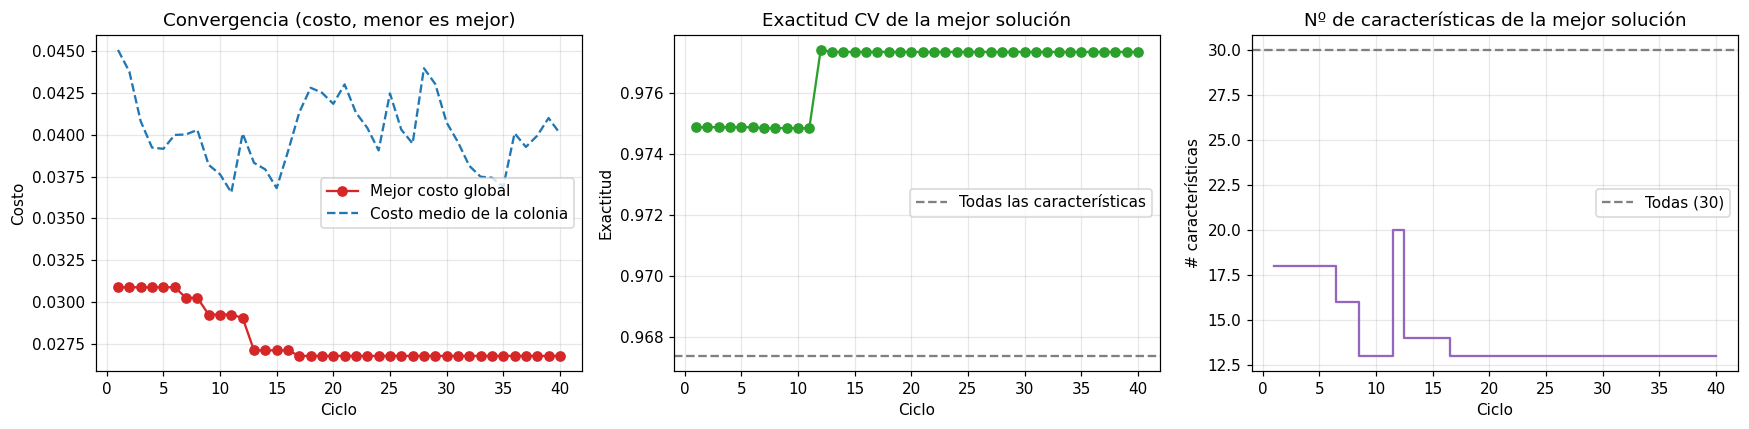

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
it = np.arange(1, MAX_ITER + 1)

ax[0].plot(it, hist["best_cost"], "o-", label="Mejor costo global", color="tab:red")
ax[0].plot(it, hist["mean_cost"], "--", label="Costo medio de la colonia", color="tab:blue")
ax[0].set(title="Convergencia (costo, menor es mejor)", xlabel="Ciclo", ylabel="Costo"); ax[0].legend()

ax[1].plot(it, hist["best_acc"], "o-", color="tab:green")
ax[1].axhline(acc_all_cv, ls="--", color="gray", label="Todas las características")
ax[1].set(title="Exactitud CV de la mejor solución", xlabel="Ciclo", ylabel="Exactitud"); ax[1].legend()

ax[2].step(it, hist["best_nfeat"], where="mid", color="tab:purple")
ax[2].axhline(D, ls="--", color="gray", label=f"Todas ({D})")
ax[2].set(title="Nº de características de la mejor solución", xlabel="Ciclo", ylabel="# características")
ax[2].legend()
plt.tight_layout(); plt.show()

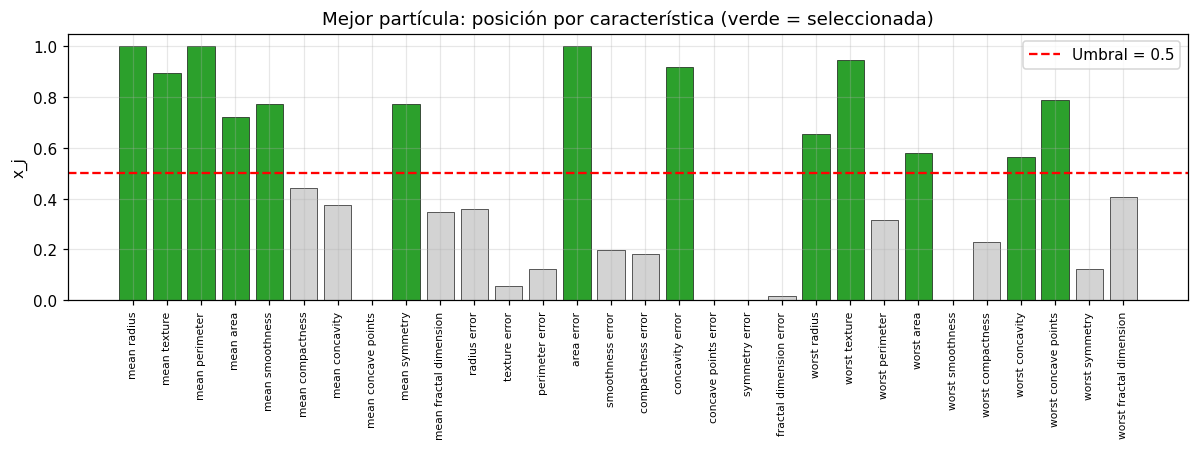

In [ ]:
# Aportes de cada característica: barras (seleccionada / no seleccionada) sobre su valor posicional final
fig, ax = plt.subplots(figsize=(11, 4.2))
colors = np.where(best_mask, "tab:green", "lightgray")
ax.bar(range(D), swarm.best_pos, color=colors, edgecolor="k", linewidth=.4)
ax.axhline(THRESH, color="red", ls="--", label=f"Umbral = {THRESH}")
ax.set_xticks(range(D)); ax.set_xticklabels(feature_names, rotation=90, fontsize=7)
ax.set(title="Mejor partícula: posición por característica (verde = seleccionada)", ylabel="x_j")
ax.legend(); plt.tight_layout(); plt.show()

## 5. Evaluación final en el conjunto de **prueba** (datos no vistos)
Se compara el modelo con las 30 características frente al modelo con el subconjunto encontrado por ABC. Como control adicional se prueban otros clasificadores (SVM y Random Forest) con **el mismo subconjunto** para ver si la selección se generaliza más allá del KNN usado en la aptitud.

In [ ]:
models = {
    "KNN (k=5)":     lambda: make_pipeline(StandardScaler(), KNeighborsClassifier(5)),
    "SVM (RBF)":     lambda: make_pipeline(StandardScaler(), SVC(random_state=SEED)),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=200, random_state=SEED),
}
all_mask = np.ones(D, dtype=bool)

rows = []
for name, mk in models.items():
    for label, m in [("Todas (30)", all_mask), (f"ABC ({best_mask.sum()})", best_mask)]:
        clf = mk().fit(X_train[:, m], y_train)
        pred = clf.predict(X_test[:, m])
        rows.append({"Modelo": name, "Características": label,
                     "Nº": int(m.sum()),
                     "Accuracy (test)": accuracy_score(y_test, pred),
                     "F1 (test)": f1_score(y_test, pred)})
res = pd.DataFrame(rows)
res.style.format({"Accuracy (test)": "{:.4f}", "F1 (test)": "{:.4f}"}).background_gradient(
    subset=["Accuracy (test)"], cmap="Greens")

,Modelo,Características,Nº,Accuracy (test),F1 (test)
0,KNN (k=5),Todas (30),30,0.9591,0.9683
1,KNN (k=5),ABC (13),13,0.9591,0.9677
2,SVM (RBF),Todas (30),30,0.9766,0.9813
3,SVM (RBF),ABC (13),13,0.9649,0.9720
4,Random Forest,Todas (30),30,0.9415,0.9537
5,Random Forest,ABC (13),13,0.9357,0.9488


In [ ]:
red = 100 * (1 - best_mask.sum() / D)
print(f"Reducción de dimensionalidad: {D} → {best_mask.sum()} características ({red:.1f} % menos).")

Reducción de dimensionalidad: 30 → 13 características (56.7 % menos).


**Lectura de la tabla.** En el conjunto de prueba (171 muestras, donde cada error equivale a ≈0.6 %), el subconjunto de ABC **iguala** al modelo completo con KNN (el clasificador usado en la aptitud) y queda a 1–2 muestras de diferencia con SVM y Random Forest, **usando menos de la mitad de las variables**. Es decir, el logro principal es la **reducción de dimensionalidad sin pérdida apreciable**, no una mejora de exactitud. La mejora de exactitud que se ve en validación cruzada durante la búsqueda es en parte optimismo del propio proceso de optimización (el enjambre "ajusta" el subconjunto a los pliegues de CV); por eso es imprescindible reportar el resultado en datos de prueba separados.

## 6. Robustez: varias ejecuciones y comparación con búsqueda aleatoria

Los algoritmos de enjambre son **estocásticos**, así que una sola ejecución no basta para sacar conclusiones. Se repite ABC con 5 semillas distintas y se compara con una **búsqueda aleatoria** que dispone del mismo presupuesto de evaluaciones (para verificar que el enjambre realmente aporta algo frente al azar). Con solo 5 repeticiones la comparación es **orientativa, no estadísticamente concluyente**.

In [ ]:
seeds = [0, 1, 2, 3, 4]
runs = []
for s in seeds:
    m, sw, h = run_abc(seed=s, verbose=False)
    clf = make_model().fit(X_train[:, m], y_train)
    runs.append({"Semilla": s, "Costo": sw.best_cost, "Acc CV": sw.best_acc,
                 "Nº caract.": int(m.sum()),
                 "Acc test": accuracy_score(y_test, clf.predict(X_test[:, m])),
                 "mask": m})
runs_df = pd.DataFrame(runs)
display(runs_df.drop(columns="mask").style.format(
    {"Costo": "{:.5f}", "Acc CV": "{:.4f}", "Acc test": "{:.4f}"}))
print("\nMedia ± desv. (ABC, 5 ejecuciones):")
print(f"  Costo      : {runs_df['Costo'].mean():.5f} ± {runs_df['Costo'].std():.5f}")
print(f"  Acc CV     : {runs_df['Acc CV'].mean():.4f} ± {runs_df['Acc CV'].std():.4f}")
print(f"  Nº caract. : {runs_df['Nº caract.'].mean():.1f} ± {runs_df['Nº caract.'].std():.1f}")
print(f"  Acc test   : {runs_df['Acc test'].mean():.4f} ± {runs_df['Acc test'].std():.4f}")

,Semilla,Costo,Acc CV,Nº caract.,Acc test
0,0,0.02640,0.9774,12,0.9532
1,1,0.02704,0.9774,14,0.9708
2,2,0.02489,0.9799,15,0.9532
3,3,0.02175,0.9824,13,0.9532
4,4,0.02673,0.9774,13,0.9649



Media ± desv. (ABC, 5 ejecuciones):
  Costo      : 0.02536 ± 0.00218
  Acc CV     : 0.9789 ± 0.0022
  Nº caract. : 13.4 ± 1.1
  Acc test   : 0.9591 ± 0.0083


Presupuesto por ejecución: 1200 evaluaciones
Búsqueda aleatoria → mejor costo medio: 0.02637 ± 0.00088
ABC                → mejor costo medio: 0.02536 ± 0.00218


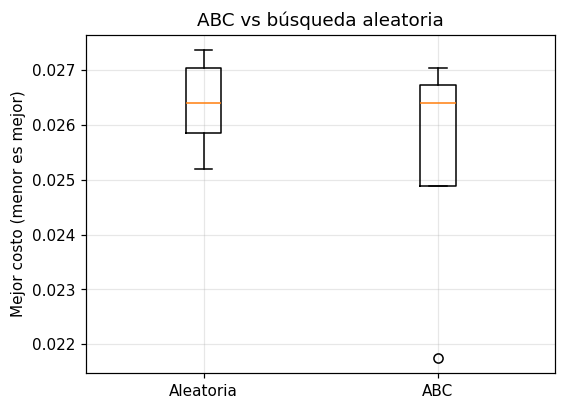

In [ ]:
# Búsqueda aleatoria con el mismo presupuesto de evaluaciones (SN + SN por ciclo ≈ 2*SN*MAX_ITER)
budget = 2 * SN * MAX_ITER
rand_costs = []
for s in seeds:
    rng = np.random.default_rng(100 + s)
    best = min(evaluate(rng.random(D))[0] for _ in range(budget))
    rand_costs.append(best)

print(f"Presupuesto por ejecución: {budget} evaluaciones")
print(f"Búsqueda aleatoria → mejor costo medio: {np.mean(rand_costs):.5f} ± {np.std(rand_costs, ddof=1):.5f}")
print(f"ABC                → mejor costo medio: {runs_df['Costo'].mean():.5f} ± {runs_df['Costo'].std():.5f}")

plt.figure(figsize=(5.5, 4))
plt.boxplot([rand_costs, runs_df["Costo"]]); plt.xticks([1, 2], ["Aleatoria", "ABC"])
plt.ylabel("Mejor costo (menor es mejor)"); plt.title("ABC vs búsqueda aleatoria"); plt.show()

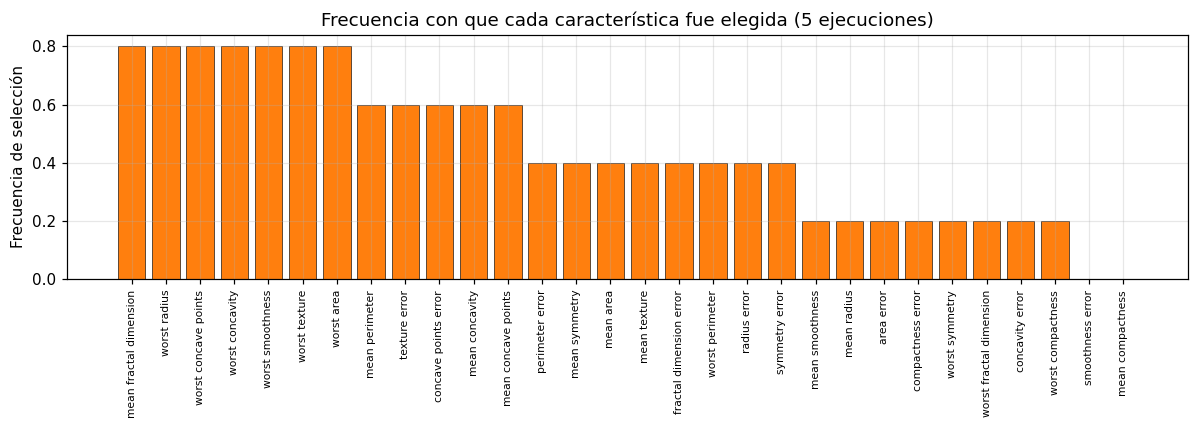

Elegidas en ≥ 4 de 5 ejecuciones: ['mean fractal dimension', 'worst radius', 'worst texture', 'worst area', 'worst smoothness', 'worst concavity', 'worst concave points']
Elegidas en las 5 ejecuciones    : ninguna (hay soluciones distintas de calidad similar)


In [ ]:
# ¿Qué características elige ABC de forma consistente?
freq = np.mean([r["mask"] for r in runs], axis=0)
order = np.argsort(-freq)
plt.figure(figsize=(11, 4))
plt.bar(range(D), freq[order], color="tab:orange", edgecolor="k", linewidth=.4)
plt.xticks(range(D), feature_names[order], rotation=90, fontsize=7)
plt.ylabel("Frecuencia de selección"); plt.title("Frecuencia con que cada característica fue elegida (5 ejecuciones)")
plt.tight_layout(); plt.show()
print("Elegidas en ≥ 4 de 5 ejecuciones:", feature_names[freq >= 0.8].tolist())
print("Elegidas en las 5 ejecuciones    :", feature_names[freq == 1.0].tolist() or "ninguna (hay soluciones distintas de calidad similar)")

## 7. Conclusiones (para el informe)

> Las cifras citadas provienen de la ejecución con las semillas fijadas en este cuaderno; al re-ejecutar en Colab pueden variar ligeramente según la versión de scikit-learn.

1. **Ciclo completo de ABC aplicado a *feature selection*:** representación continua + umbral (vector en $[0,1]^{30}$ → máscara binaria), inicialización aleatoria uniforme, aptitud *wrapper* (KNN + validación cruzada + penalización por número de variables), tres tipos de abejas (empleadas, observadoras, exploradoras), evolución por ciclos con selección voraz y finalización por número máximo de ciclos.
2. **Reducción de dimensionalidad:** ABC pasó de 30 a ≈13 características (≈57 % menos). En validación cruzada la exactitud subió de ≈0.967 (30 variables) a ≈0.977–0.979.
3. **Desempeño en datos no vistos:** con KNN, la exactitud en prueba es **igual** a la del modelo completo (≈0.959). Con SVM y Random Forest hay una diferencia de 1–2 muestras a favor del modelo completo. La conclusión honesta es: *mismo desempeño con menos de la mitad de las variables*, lo cual implica modelos más simples, rápidos e interpretables.
4. **Sobreajuste a la búsqueda:** la ganancia en CV no se traslada íntegramente al test, un fenómeno típico de los métodos *wrapper*. Por eso la evaluación final se hace con un conjunto de prueba que el enjambre nunca vio.
5. **ABC vs. búsqueda aleatoria:** con el mismo presupuesto, ABC obtiene un costo medio algo menor, pero la diferencia es pequeña y con 5 ejecuciones no es concluyente. Esto es esperable en un problema de solo 30 variables, donde el espacio es relativamente pequeño; la ventaja de los enjambres crece con la dimensionalidad ($D$ de cientos o miles).
6. **Estabilidad:** ejecuciones distintas hallan subconjuntos distintos pero de calidad similar (hay muchas variables correlacionadas entre sí, p. ej. radio, perímetro y área), de modo que no existe un único "mejor subconjunto".
7. **Limitaciones y mejoras posibles:** costo computacional de la evaluación *wrapper*; sensibilidad a `SN`, `LIMIT`, `MR` y $\alpha$; podrían probarse funciones de transferencia (sigmoide) para binarizar, otros clasificadores y validación cruzada repetida para reducir el sobreajuste.

### Referencias
* Karaboga, D. (2005). *An idea based on honey bee swarm for numerical optimization*. Technical Report TR06, Erciyes University.
* Karaboga, D., & Basturk, B. (2007). A powerful and efficient algorithm for numerical function optimization: artificial bee colony (ABC) algorithm. *Journal of Global Optimization*, 39, 459–471.
* Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.